going for a notebook approach for yolo now , using yolo v11m

In [1]:
from ultralytics import YOLO

import os
from PIL import Image

import torch
from torchvision import transforms

import matplotlib.pyplot as plt

instantiating gpu use

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'device: {device}')  

device: cuda


the images and labels

In [3]:
TRAIN_IMG_DIR = 'data/images/train'
VAL_IMG_DIR   = 'data/images/test'
TEST_IMG_DIR = 'data/images/validate'

In [4]:
print(f"total training arrow images: {len(os.listdir(TRAIN_IMG_DIR))}")
print(f"total validation arrow images: {len(os.listdir(VAL_IMG_DIR))}")
print(f"total testing arrow images: {len(os.listdir(TEST_IMG_DIR))}")

total training arrow images: 2673
total validation arrow images: 402
total testing arrow images: 136


In [5]:
TRAIN_LABELS_DIR = 'data/labels/train'
VAL_LABELS_DIR   = 'data/labels/test' 
TEST_LABELS_DIR = 'data/labels/validate'

In [6]:
print(f"total training arrow labels: {len(os.listdir(TRAIN_LABELS_DIR))}")
print(f"total validation arrow labels: {len(os.listdir(VAL_LABELS_DIR))}")
print(f"total testing arrow labels: {len(os.listdir(TEST_LABELS_DIR))}")

total training arrow labels: 2673
total validation arrow labels: 402
total testing arrow labels: 136


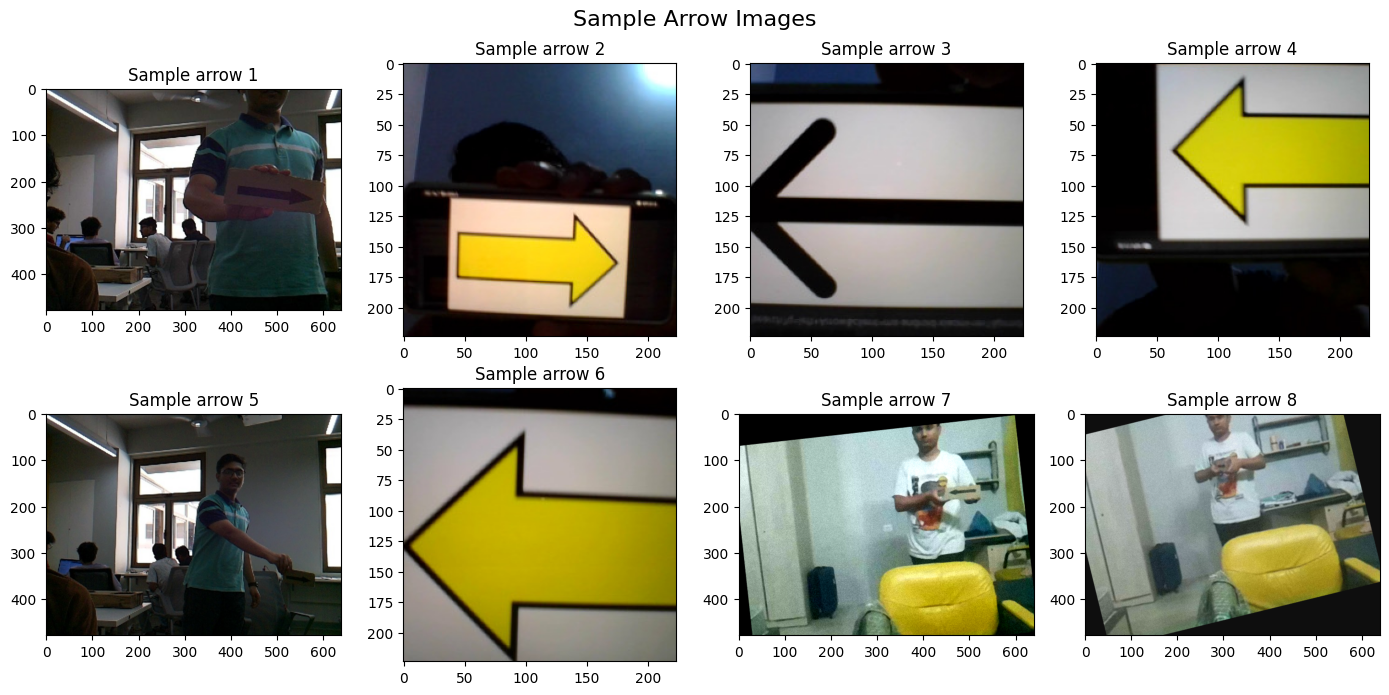

In [7]:
arrow_images = [os.path.join(TRAIN_IMG_DIR, filename) for filename in os.listdir(TRAIN_IMG_DIR) 
                if filename.lower().endswith(('.png', '.jpg', '.jpeg'))]

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
fig.suptitle('Sample Arrow Images', fontsize=16)

for i, arrow_image in enumerate(arrow_images[:8]):
    img = Image.open(arrow_image)
    row = i // 4  
    col = i % 4   
    
    axes[row, col].imshow(img)
    axes[row, col].set_title(f'Sample arrow {i+1}')

plt.tight_layout()
plt.show()

final model construction

In [8]:
model = YOLO('yolo11m.pt')
model.info()

YOLO11m summary: 231 layers, 20,114,688 parameters, 0 gradients, 68.5 GFLOPs


(231, 20114688, 0, 68.52838399999999)

In [9]:
model.train(
    # SETUP
    data='config.yaml',
    epochs=400,            
    patience=25,           
    batch=16,               
    device=0,
    freeze=6,              
    optimizer='Adam',
    lr0=0.0003,            
    lrf=0.01,
    weight_decay=0.0005,
    warmup_epochs=5,       
    warmup_bias_lr=0.1,
    dropout=0.4,           
    
    # DATA AUGMENTATION 
    degrees=20.0,          
    scale=0.15,            
    translate=0.08,        
    perspective=0.0003,    
    shear=2.0,             
    fliplr=0.0,            
    hsv_h=0.02,            
    hsv_s=0.7,             
    hsv_v=0.4,             
    mixup=0.1,             
    copy_paste=0.2,        
    
    # OPTIMIZING LOSS FUNCTION
    cls=2.0,              
    box=7.5,               
    dfl=2.0                
)

Ultralytics 8.3.169 🚀 Python-3.12.11 torch-2.7.1+cu126 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 7797MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=2.0, conf=None, copy_paste=0.2, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=config.yaml, degrees=20.0, deterministic=True, device=0, dfl=2.0, dnn=False, dropout=0.4, dynamic=False, embed=None, epochs=400, erasing=0.4, exist_ok=False, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=6, half=False, hsv_h=0.02, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0003, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolo11m.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=Adam, overlap_mask=True, patience=25, perspective=0.0003, plots=True, pose=12.0, pre

100%|██████████| 5.35M/5.35M [00:10<00:00, 560kB/s]


AMP: checks passed ✅
train: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3680.3±2440.4 MB/s, size: 260.5 KB)


train: Scanning /home/pranav/Projects/arrow_detection/data/labels/train.cache... 2673 images, 28 backgrounds, 0 corrupt: 100%|██████████| 2673/2673 [00:00<?, ?it/s]


val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 538.7±237.9 MB/s, size: 13.4 KB)


...

                   all        402        402      0.996          1      0.995      0.747
EarlyStopping: Training stopped early as no improvement observed in last 25 epochs. Best results observed at epoch 22, best model saved as best.pt.
To update EarlyStopping(patience=25) pass a new patience value, i.e. `patience=300` or use `patience=0` to disable EarlyStopping.



47 epochs completed in 0.735 hours.
Optimizer stripped from runs/detect/train/weights/last.pt, 40.5MB
Optimizer stripped from runs/detect/train/weights/best.pt, 40.5MB

Validating runs/detect/train/weights/best.pt...
Ultralytics 8.3.169 🚀 Python-3.12.11 torch-2.7.1+cu126 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 7797MiB)
YOLO11m summary (fused): 125 layers, 20,031,574 parameters, 0 gradients, 67.7 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 13/13 [00:04<00:00,  2.82it/s]


                   all        402        402      0.993      0.996      0.995      0.771
                  left        201        201      0.995      0.995      0.995      0.827
                 right        201        201       0.99      0.997      0.995      0.715
Speed: 0.2ms preprocess, 9.5ms inference, 0.0ms loss, 0.6ms postprocess per image
Results saved to runs/detect/train


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7f5388108140>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804

satisfactory results however false positives are still quite prevalent